# Taller 7 · DFT I: Espectro de amplitud y representación

**Asignatura:** Teoría de la Información y Procesado de Señal
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**
**Duración:** 2 horas
**Modalidad:** Jupyter Notebook con asistencia de IA

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Calcular la **DFT mediante FFT** y construir correctamente el **eje de frecuencias**.
2. Representar el **espectro de amplitud** en sus distintas formas: raw, centrado, completo y one-sided.
3. Interpretar frecuencias normalizadas (ciclos/muestra) y su correspondencia con Hz.
4. Entender la **resolución frecuencial** $\Delta f = F_s / N$ y su efecto.
5. Representar espectros en **escala lineal y logarítmica (dB)**.
6. Analizar dos propiedades: relación de Parseval y linealidad.

---

## Reto central del taller

> **De la señal temporal al espectro: ¿cómo interpretar correctamente lo que devuelve la FFT?**
>
> En este taller construirás paso a paso las distintas representaciones del espectro de amplitud,
> entenderás la relación entre frecuencias normalizadas y Hz, y descubrirás por qué no todas las
> frecuencias se ven igual en el espectro.

---

## Metodología de trabajo con IA

| Puedes pedir a la IA | NO debes pedir a la IA |
|---------------------|------------------------|
| Código de FFT y visualización | Que interprete los espectros |
| Sintaxis de `fftfreq`, `fftshift` | Que explique resultados sin analisis por tu parte |
| Construcción del eje de frecuencias | Que responda las preguntas de control |

> *La IA te ayuda a escribir código, pero no a entender espectros. Eso es tu trabajo.*

---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** López Bazarra

- **Nombre:** Juan

- **Email UDC:** juan.bazarra@udc.es

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

print("✓ Entorno listo")

✓ Entorno listo


---

## Parte 1: Generación de la señal de trabajo

### Contexto teórico

A partir de una señal analógica que es la suma de una constante y un tono sinusoidal:

$$x_a(t) = C + A \sin(2\pi F_a t)$$

la muestreamos a $F_s$ Hz para obtener la señal discreta:

$$x(n) = C + A \sin\left(2\pi \frac{F_a}{F_s} n\right) = C + A \sin(2\pi f_a\, n), \quad 0 \le n < N$$

donde $f_a = F_a / F_s$ es la **frecuencia normalizada** en ciclos/muestra.

**En este taller, la señal de partida será:**
- $C = 0.1$ (componente DC)
- $A = 0.4$ (amplitud del tono)
- $F_a = 3000$ Hz
- $F_s = 8000$ Hz → $f_a = 3/8$ ciclos/muestra
- Duración: 500 ms

---

### Bloque 1 · Generación del tono

#### 📝 Hipótesis previa

**Preguntas:**

- ¿Se cumplen las condiciones del teorema de muestreo con $F_a = 3$ kHz y $F_s = 8$ kHz? No, porque $F_a$ es mayor que $F_s/2$ (4000 Hz), lo que implica que la señal estará sujeta a aliasing.
- ¿Cuál es el período de $x(n)$ en muestras? (Pista: piensa en $f_a = 3/8$) El período de $x(n)$ en muestras se puede calcular como el inverso de la frecuencia normalizada $f_a$. Dado que $f_a = 3/8$ ciclos/muestra, el período en muestras es:
P = 1 / f_a = 1 / (3/8) = 8/3 ≈ 2.67 muestras.
- ¿Cuál es el valor medio de la señal? El valor medio de la señal es C = 0.1, ya que el componente DC representa el valor alrededor del cual oscila la señal.

In [20]:
# === PARÁMETROS ===
Fs = 8000               # frecuencia de muestreo en Hz
Ts = 1 / Fs             # período de muestreo
Fa = 3000               # frecuencia del tono en Hz
C = 0.1                 # componente DC
A = 0.4                 # amplitud del tono
duracion = 500e-3       # 500 ms

# TODO: Calcula la frecuencia normalizada (ciclos/muestra), fa
fa = Fa / Fs



# TODO: Genera el vector de índices (de 0 a N-1, donde N = duracion * Fs), n
N_total= int(duracion * Fs)
n = np.arange(N_total)



# TODO: Genera la señal x(n), x
x = C + A * np.sin(2 * np.pi * fa * n)


In [21]:
# === VALIDACIÓN ===
assert x is not None, "Genera la señal x(n)"
assert len(x) == N_total, "La señal debe tener N_total muestras"

print(f"Frecuencia de muestreo: Fs = {Fs} Hz")
print(f"Frecuencia del tono: Fa = {Fa} Hz")
print(f"Frecuencia normalizada: fa = {fa} = {Fraction(Fa, Fs)} ciclos/muestra")
print(f"Número total de muestras: N_total = {N_total}")
print(f"Valor medio de x(n): {np.mean(x):.4f} (esperado: {C})")

Frecuencia de muestreo: Fs = 8000 Hz
Frecuencia del tono: Fa = 3000 Hz
Frecuencia normalizada: fa = 0.375 = 3/8 ciclos/muestra
Número total de muestras: N_total = 4000
Valor medio de x(n): 0.1000 (esperado: 0.1)


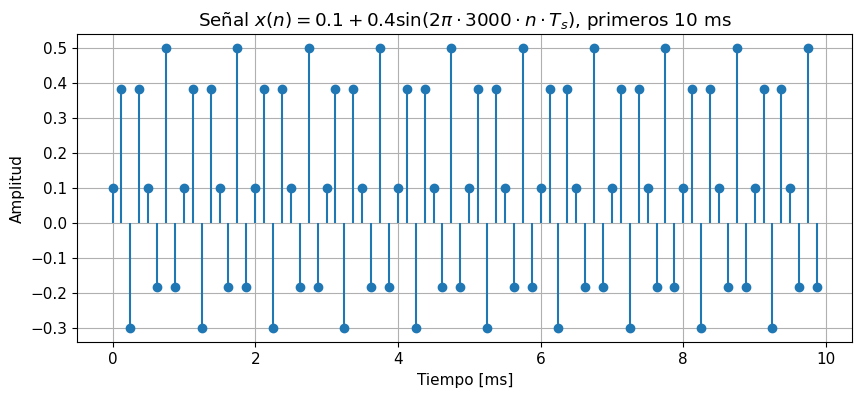

In [22]:
# === VISUALIZACIÓN: primeros 10 ms ===
display_ms = 10e-3
n_display = int(display_ms * Fs)
t_display = n[:n_display] * Ts * 1e3  # en ms

plt.figure(figsize=(10, 4))
plt.stem(t_display, x[:n_display], basefmt=' ')
plt.xlabel('Tiempo [ms]')
plt.ylabel('Amplitud')
plt.title(f'Señal $x(n) = {C} + {A} \\sin(2\\pi \\cdot {Fa} \\cdot n \\cdot T_s)$, primeros {display_ms*1e3:.0f} ms')
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Cuál es el período de $x(n)$ en muestras? ¿Es intuitivo viéndolo en la gráfica?**

*Tu respuesta:*

```
El período de $x(n)$ en muestras se puede calcular como el inverso de la frecuencia normalizada $f_a$. Dado que $f_a = 3/8$ ciclos/muestra, el período en muestras es:
P = 1 / f_a = 1 / (3/8) = 8/3 ≈ 2.67 muestras.
```

**2. ¿Qué representa la constante C y cómo se ve en la señal?**

*Tu respuesta:*

```
Representa el componente DC de la señal, es decir, el valor medio alrededor del cual oscila el tono sinusoidal. En la gráfica, se verá como un desplazamiento vertical de la señal hacia arriba, ya que C = 0.1.
```

**4. ¿Cuál es la amplitud del tono sinusoidal?**

*Tu respuesta:*

```
La amplitud del tono sinusoidal es A = 0.4, lo que significa que la señal oscilará entre C - A = -0.3 y C + A = 0.5.
```

## Parte 2: Transformada Discreta de Fourier (DFT) y espectro de amplitud
 
### Contexto teórico
 
La **DFT** de $N$ puntos de una secuencia $x(n)$ produce $N$ coeficientes complejos:
 
$$X(k) = \sum_{n=0}^{N-1} x(n)\, e^{-j 2\pi k n / N}, \quad k = 0, 1, \ldots, N-1$$
 
A partir de la DFT, se define el espectro de amplitud, que se usa para que las amplitudes de las componentes sinusoidales de la señal tengan una correspondencia con las amplitudes representadas en cada frecuencia del espectro, facilitando así su interpretación física. Este **espectro de amplitud** se obtiene normalizando el módulo:
 
$$A(k) = \frac{1}{N} |X(k)|$$
 
Las frecuencias correspondientes a cada $k$ son $f_k = k/N$ ciclos/muestra, en el intervalo $[0, 1)$.
 
**Importante:** La FFT no "sabe" nada de $F_s$, ya que como ves las frecuencias normalizadas $f_k$ siempre están en el intervalo $[0, 1)$. Somos nosotros los que interpretamos los bins en función de $F_s$ y $N$.
 
---

### Cálculo de la DFT con NumPy y la función FFT
NumPy proporciona una implementación de la FFT que está documentada en https://numpy.org/doc/stable/reference/routines.fft.html. Para calcular la FFT de ```N``` muestras de un vector ```x```, que representa la secuencia discreta $x(n)$ de $N$ muestras obtenidas por muestreo uniforme a la frecuencia $F_s$, se utiliza el código siguiente:

```X : np.ndarray[float] = np.fft.fft(x, N)```

Los $N$ elementos del vector ```X``` se corresponden con las $N$ muestras de $X(k)$ de la frecuencia normalizada (respecto a $F_s$) de la señal discreta. Como sabemos (y repasaremos en este taller), la DFT es periódica con periodo $1$ ($F_s$ si no las consideramos normalizadas). De esta forma, las ```N``` muestras de la frecuencia se reparten en el intervalo $[0,1)$, o lo que es equivalente, entre $[-1/2, 1/2)$. Este último intervalo es el que se considera en la siguiente figura para $N = 16$ muestras (observa como se considera la periodicidad para la representación de los valores de la derecha del vector):

<img src="../helpers/fft.svg" width="700"/>

* ```X[0]``` es la muestra para la frecuencia $f_0 = 0$ ciclos/muestra y aparece en color gris en la figura.
* ```X[1:N/2]``` contiene las $\frac{N}{2} - 1$ muestras para las frecuencias positivas $f_k \in \{\frac{1}{N}, \frac{2}{N}, \dots, \frac{(N/2)-1}{N}\}$ ciclos/muestra, en color rojizo.
* ```X[N/2:]``` contiene las $\frac{N}{2}$ muestras para las frecuencias negativas $f_k \in \{\frac{-1}{2}, -\frac{(N/2)-1}{N}, \dots, \frac{-1}{N}\}$ ciclos/muestra. Están coloreadas en azul, excepto la muestra para la frecuencia más negativa de $\frac{-1}{2}$ ciclos/muestra que es verde. 

Observa su correspondencia con los valores negativos de las frecuencias normalizadas que siguen la siguiente correspondiencia debido a su carácter periodico (piensa que al dar un ciclo completo, volvemos al principio):




| $\boldsymbol{k}$ | $\cdots$ | $-N$ | $\cdots$ | $\boldsymbol{-N/2}$ | $\boldsymbol{-(N/2-1)}$ | $\boldsymbol{\cdots}$ | $\boldsymbol{-1}$ | $\boldsymbol{0}$ | $\boldsymbol{1}$ | $\boldsymbol{\cdots}$ | $\boldsymbol{(N/2-1)}$ | $N/2$ | $N/2+1$ | $\cdots$ | $N$ | $\cdots$ |
|------------------|----------|------|----------|---------------------|-------------------------|----------------------|-------------------|-------------------|-------------------|----------------------|-----------------------|------|--------|----------|-----|---------|
| $\boldsymbol{f_k}$ | $\cdots$ | $-1$ | $\cdots$ | $\boldsymbol{-1/2}$ | $\boldsymbol{-(1/2-1/N)}$ | $\cdots$ | $\boldsymbol{-1/N}$ | $\boldsymbol{0}$ | $\boldsymbol{1/N}$ | $\boldsymbol{\cdots}$ | $\boldsymbol{(1/2-1/N)}$ | $1/2$ | $1/2+1/N$ | $\cdots$ | $1$ | $\cdots$ |





### Bloque 2 · Espectro de amplitud (FFT sin centrar)

Para este primer análisis, tomaremos una ventana corta de **$N = 16$ muestras** de $x(n)$.
 
#### 📝 Hipótesis previa
 
**Preguntas:**
 
- Con $N = 16$ muestras, ¿cuántos bins de la DFT obtendremos? obtenemos 16 bins, ya que la DFT de una secuencia de $N$ muestras produce $N$ coeficientes complejos.
- Si $f_a = 3/8$ ciclos/muestra, ¿en qué bin $k$ esperas ver un pico? (Pista: $f_k = k/N$, despeja $k$) Si $f_k = k/N$ y $f_a = 3/8$, entonces despejando $k$ tenemos:
k = f_a * N = (3/8) * 16 = 6
Por lo tanto, esperamos ver un pico en el bin $k = 6$.
- ¿Cuál será la amplitud del pico del tono? (Pista: piensa en la contribución de frecuencias positivas y negativas) La amplitud del pico del tono se puede calcular considerando que el tono sinusoidal contribuye tanto a la frecuencia positiva como a la negativa. Dado que la amplitud del tono es A = 0.4, y considerando la normalización por N, la amplitud del pico en el espectro de amplitud será aproximadamente A/2 = 0.2 en cada uno de los bins correspondientes a las frecuencias positiva y negativa.

---

In [5]:
# === IMPLEMENTACIÓN ===
# Ventana de N=16 muestras
N = 16
nmin = 0
nmax = nmin + N

# Extraemos el segmento de la señal
xtime = x[nmin:nmax]

# TODO: Calcula la DFT de xtime usando np.fft.fft(), Xfreq
Xfreq = np.fft.fft(xtime)



# TODO: Calcula el espectro de amplitud normalizado, Afreq
Afreq = np.abs(Xfreq) / N


N = 16 muestras
Afreq = [0.1 0.  0.  0.  0.  0.  0.2 0.  0.  0.  0.2 0.  0.  0.  0.  0. ]


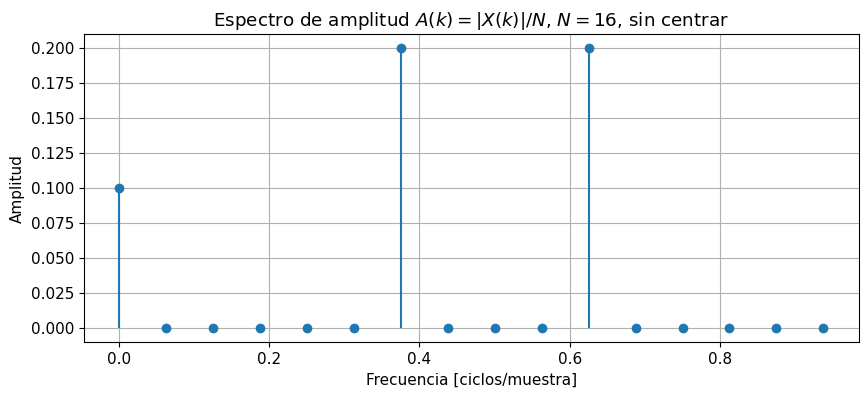

In [6]:
# === VALIDACIÓN ===
assert Xfreq is not None, "Calcula la DFT con np.fft.fft()"
assert Afreq is not None, "Calcula el espectro de amplitud"
assert len(Xfreq) == N, "La DFT debe tener N puntos"

print(f"N = {N} muestras")
print(f"Afreq = {np.array2string(Afreq, precision=4, suppress_small=True)}")

# === VISUALIZACIÓN ===
# Eje de frecuencias en ciclos/muestra: fk = k/N para k = 0, ..., N-1
Fk = [Fraction(k, N) for k in range(N)]
fkFloat = [float(f) for f in Fk]

plt.figure(figsize=(10, 4))
plt.stem(Fk, Afreq, basefmt=' ')
plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud $A(k) = |X(k)|/N$, $N = {N}$, sin centrar')
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué frecuencias predominan en el espectro? ¿En qué bins $k$ caen?**

*Tu respuesta:*

```
Las frecuencias predominantes en el espectro serán la componente DC (frecuencia 0) y el tono sinusoidal a $f_a = 3/8$ ciclos/muestra. La componente DC aparecerá en el bin $k=0$, mientras que el tono sinusoidal aparecerá principalmente en el bin $k=6$, que corresponde a la frecuencia normalizada de $3/8$ ciclos/muestra.
```

**2. ¿Qué relación guardan esas frecuencias con $f_a = 3/8$ ciclos/muestra de la señal original?**

*Tu respuesta:*

```
La frecuencia del tono sinusoidal en la señal original es $f_a = 3/8$ ciclos/muestra, lo que corresponde exactamente al bin $k=6$ en el espectro de la DFT, ya que $f_k = k/N$ y para $k=6$ tenemos $f_6 = 6/16 = 3/8$ ciclos/muestra. Esto confirma que el pico en el bin $k=6$ se debe al tono sinusoidal presente en la señal original.
```

**3. ¿Qué relación hay entre las amplitudes de las deltas con las amplitudes de las dos componentes de la señal (DC y tono)?**

*Tu respuesta:*

```
La amplitud del pico correspondiente a la componente DC en el bin $k=0$ será aproximadamente igual a C = 0.1, ya que el componente DC contribuye principalmente a ese bin. Por otro lado, la amplitud del pico correspondiente al tono sinusoidal en el bin $k=6$ será aproximadamente A/2 = 0.2, debido a que el tono sinusoidal contribuye tanto a la frecuencia positiva como a la negativa, y la normalización por N distribuye la amplitud entre ambos bins.
```

---

## Parte 3: Espectro centrado en la frecuencia DC

### Contexto teórico

A la hora de dibujar los valores de amplitud, módulo y/o fase de las muestras $X(k)$ del espectro es más conveniente la representación más natural, con las frecuencias negativas a la izquierda del eje de ordenadas, la frecuencia 0 sobre dicho eje de ordenadas y las frecuencias positivas a su derecha. Para ello, se utilizará ```fftshift()```, con la que las $N$ muestras $X(k)$ del espectro se reorganizan con el código siguiente, obteniendo el resultado de la figura de abajo: 

```X : np.ndarray[float] = np.fft.fftshift( np.fft.fft(x, N) )```

<img src="../helpers/fftshift.svg" width="700"/>

* ```X[0:N/2]``` contiene las $\frac{N}{2}$ muestras del espectro para las frecuencias negativas $f_k \in \{\frac{-1}{2}, -\frac{(N/2)-1}{N}, \dots, \frac{-1}{N}\}$ ciclos/muestra. Están coloreadas en azul, excepto la más negativa que está en color verde. 
* ```X[N/2]``` es la muestra del espectro para la frecuencia $0$ y está en color gris.
* ```X[(N/2)+1 : N]``` contiene las $\frac{N}{2} - 1$ muestras del espectro para las frecuencias positivas $f_k \in \{\frac{1}{N}, \frac{2}{N}, \dots, \frac{(N/2)-1}{N}\}$ ciclos/muestra. Están coloreadas en rojo en la figura.

---

### Bloque 3 · Espectro centrado con `fftshift`

#### 📝 Hipótesis previa

**Pregunta:** Después de centrar, ¿dónde esperas ver las dos deltas del tono respecto al eje de ordenadas?

*Tu predicción:* `Las dos deltas del tono se esperaría ver simétricamente alrededor del eje de ordenadas, con una delta a la izquierda (frecuencia negativa) y otra a la derecha (frecuencia positiva) del bin correspondiente a la frecuencia 0.
`

In [7]:
# === IMPLEMENTACIÓN ===

# TODO: Centra el espectro de amplitud usando np.fft.fftshift(), obteniendo Afreqcentrado
Afreqcentrado = np.fft.fftshift(Afreq)  


# TODO: Calcula el espectro de amplitud centrado hecho por ti con manimulación de vectores, Afreqcentradoporvectores
Afreqcentradoporvectores = np.zeros_like(Afreq)
for k in range(N):
    k_centrado = (k + N//2) % N  # Índice centrado
    Afreqcentradoporvectores[k_centrado] = Afreq[k] 
    


Afreqcentrado = [0.  0.  0.2 0.  0.  0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.2 0. ]


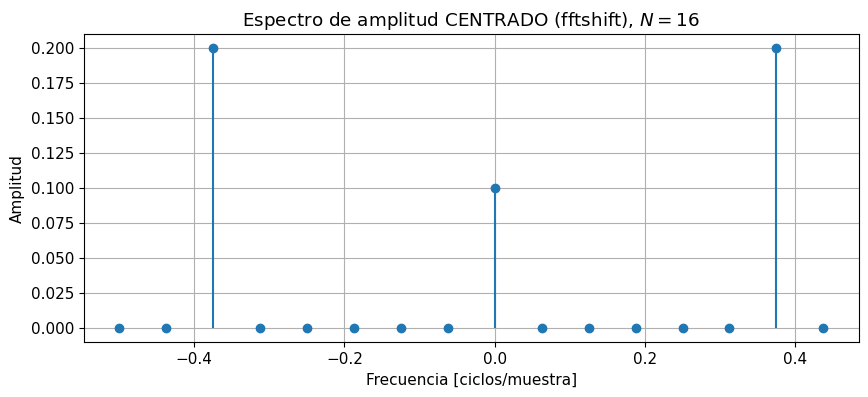


¿Las deltas están en ±3/8 ciclos/muestra? Compruébalo visualmente.


In [8]:
# === VALIDACIÓN ===
assert Afreqcentrado is not None, "Centra el espectro con fftshift"
assert Afreqcentradoporvectores is not None, "Centra el espectro con manimulación de vectores"
assert np.allclose(Afreqcentrado, Afreqcentradoporvectores), "Los dos espectros centrados deben ser iguales"
print(f"Afreqcentrado = {np.array2string(Afreqcentrado, precision=4, suppress_small=True)}")

# === VISUALIZACIÓN ===
# Eje de frecuencias centrado: k/N para k = -N/2, ..., N/2-1
Fk_centered = [Fraction(k, N) for k in range(-N // 2, N // 2)]
fk_centered_float = [float(f) for f in Fk_centered]

plt.figure(figsize=(10, 4))
plt.stem(Fk_centered, Afreqcentrado, basefmt=' ')
plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud CENTRADO (fftshift), $N = {N}$')
plt.show()

# Verificación
print(f"\n¿Las deltas están en ±{Fraction(Fa, Fs)} ciclos/muestra? Compruébalo visualmente.")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Dónde caen ahora las dos deltas? ¿Coincide con $\pm f_a = \pm 3/8$ ciclos/muestra?**

*Tu respuesta:*

```
Después de centrar el espectro con `fftshift()`, las dos deltas correspondientes al tono sinusoidal deberían aparecer simétricamente alrededor del eje de ordenadas. La delta para la frecuencia positiva debería estar a la derecha del bin correspondiente a la frecuencia 0, mientras que la delta para la frecuencia negativa debería estar a la izquierda. Ambas deltas deberían coincidir con $\pm f_a = \pm 3/8$ ciclos/muestra, lo que corresponde a los bins $k = \pm 6$ en el espectro centrado.
```

**2. ¿Por qué esta representación es más natural que la del Bloque 2?**

*Tu respuesta:*

```
Esta representación es más natural porque al centrar el espectro con `fftshift()`, las frecuencias negativas y positivas se organizan de manera simétrica alrededor de la frecuencia 0. Esto facilita la interpretación visual del espectro, ya que las componentes de frecuencia se distribuyen de forma intuitiva, con las frecuencias negativas a la izquierda y las positivas a la derecha del eje de ordenadas. En contraste, en la representación sin centrar, las frecuencias negativas y positivas están mezcladas, lo que puede dificultar la identificación de las componentes de frecuencia y su relación con la señal original.
```

**3. ¿Hay el mismo número de bins de frecuencia negativos que positivos? ¿Por qué?**

*Tu respuesta:*

```
sí, hay el mismo número de bins de frecuencia negativos que positivos debido a la simetría inherente en la DFT. Para una DFT de $N$ puntos, hay $N/2$ bins correspondientes a frecuencias positivas y $N/2$ bins correspondientes a frecuencias negativas (incluyendo la frecuencia 0). Esta simetría se debe a la periodicidad de la DFT y a cómo se asignan las frecuencias en el espectro.
```

---

## Parte 4: Periodicidad de la DFT y espectro completo

### Contexto teórico

La DFT es **periódica** con período $N$: $X(k) = X(k + N)$.

El espectro centrado con `fftshift` tiene $N$ muestras en el intervalo $[-1/2, 1/2)$ ciclos/muestra. Observa que el intervalo es **abierto por la derecha**: no incluye $+1/2$.

Para obtener un espectro con el **mismo número de muestras** a izquierda y derecha ($N/2$ negativas + DC + $N/2$ positivas = $N+1$ muestras), aprovechamos la periodicidad: la muestra en $-1/2$ es la misma que en $+1/2$, por lo que podemos añadirlo al final del vector, obtienendo esa muestra adicional que necesitamos para octener el espectro completo y simétrico.

<img src="../helpers/fftperiodic.svg" width="800"/>

---

### Bloque 4 · Espectro completo simétrico

#### 📝 Hipótesis previa

**Pregunta:** ¿Cuántas muestras tendrá el espectro completo simétrico? Tendrá $N+1$ muestras, ya que se añade la muestra correspondiente a $+1/2$ ciclos/muestra al final del vector centrado, aprovechando la periodicidad de la DFT.

In [9]:
# === IMPLEMENTACIÓN ===

# TODO: Construye el espectro completo (Afreqcompleto), a partir del espectro centrado (Afreqcentrado),
# añadiendo la muestra de +1/2
# Puedes usar np.append() o np.concatenate()
Afreqcompleto = np.append(Afreqcentrado, Afreqcentrado[0])  # Añade la muestra de +1/2 al final



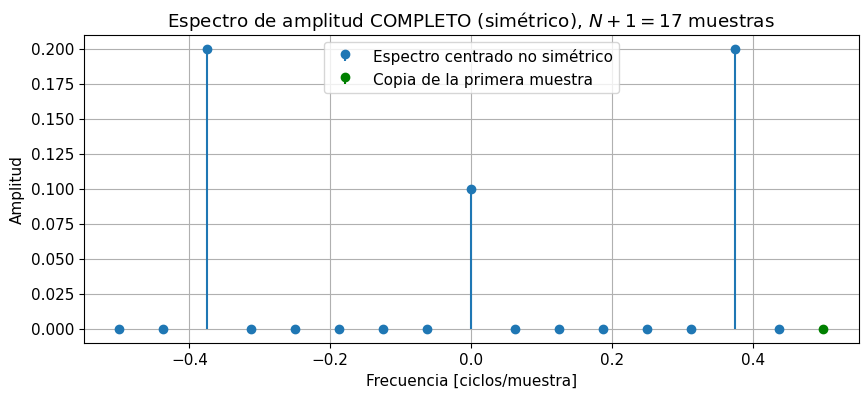

Muestras en el espectro completo: 17
  - 8 negativas + 1 DC + 8 positivas = 17


In [10]:
# === VALIDACIÓN ===
assert Afreqcompleto is not None, "Construye el espectro completo"
assert len(Afreqcompleto) == N + 1, f"El espectro completo debe tener N+1 = {N+1} muestras"

# === VISUALIZACIÓN ===
Fk_completo = [Fraction(k, N) for k in range(-N // 2, N // 2 + 1)]
fk_completo_float = [float(f) for f in Fk_completo]

plt.figure(figsize=(10, 4))
# Pintamos todas menos la última muestra en azul
(markerline, stemlines, baseline) = plt.stem(
    Fk_completo[:-1],
    Afreqcompleto[:-1],
    basefmt=' ',
    linefmt='C0-',
    markerfmt='C0o',
    label="Espectro centrado no simétrico"
)

# Pintamos la última muestra (la copia de la primera) en verde
plt.stem(
    [Fk_completo[-1]],
    [Afreqcompleto[-1]],
    basefmt=' ',
    linefmt='g-',
    markerfmt='go',
    label="Copia de la primera muestra"
)

plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud COMPLETO (simétrico), $N+1 = {N+1}$ muestras')
plt.legend()
plt.show()

print(f"Muestras en el espectro completo: {len(Afreqcompleto)}")
print(f"  - {N//2} negativas + 1 DC + {N//2} positivas = {N+1}")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué propiedad de la DFT nos justifica que la muestra de $+1/2$ se puede obtener a partir de la de $-1/2$?**

*Tu respuesta:*

```
La propiedad de la DFT que nos justifica que la muestra de $+1/2$ se puede obtener a partir de la de $-1/2$ es la periodicidad de la DFT. Dado que $X(k) = X(k + N)$, esto implica que el valor del espectro en $-1/2$ ciclos/muestra es el mismo que en $+1/2$ ciclos/muestra. Por lo tanto, podemos añadir la muestra correspondiente a $+1/2$ al final del vector centrado sin perder información, obteniendo así un espectro completo y simétrico con $N+1$ muestras.
```

**2. Razona porque el espectro centrado simétrico tiene las frecuencias en el intervalo $[-1/2, 1/2]$ ciclos/muestra.**

*Tu respuesta:*

```
El espectro centrado simétrico tiene las frecuencias en el intervalo $[-1/2, 1/2]$ ciclos/muestra debido a la forma en que se organiza la DFT después de aplicar `fftshift()`. Al centrar el espectro, las frecuencias negativas se colocan a la izquierda del eje de ordenadas, la frecuencia 0 se coloca en el centro, y las frecuencias positivas se colocan a la derecha. Esto crea una representación simétrica del espectro alrededor de la frecuencia 0, con las frecuencias negativas extendiéndose hasta $-1/2$ ciclos/muestra y las frecuencias positivas extendiéndose hasta justo antes de $+1/2$ ciclos/muestra. La periodicidad de la DFT asegura que el valor en $+1/2$ es el mismo que en $-1/2$, lo que permite cerrar el intervalo de manera simétrica.
```

---

## Parte 5: Redundancia del espectro y espectro one-sided

### Contexto teórico

Si $x(n) \in \mathbb{R}$, la DFT tiene **simetría conjugada** (hermítica):

$$X(k)^* = X(-k) \quad \Rightarrow \quad |X(k)| = |X(-k)|$$

Esto significa que las frecuencias negativas son redundantes: toda la información está en las **frecuencias positivas** (y la DC). Es suficiente representar las $N/2 + 1$ muestras del espectro para $f_k \in [0, 1/2]$ ciclos/muestra.

**Normalización one-sided:** Para conservar la energía total, **duplicamos** la amplitud de las frecuencias positivas (excepto DC y Nyquist ($1/2$), que no tienen "espejo"):

$$A_{\text{os}}(k) = \begin{cases} A(k) & \text{si } k = 0 \text{ o } k = N/2 \\ 2 \cdot A(k) & k=1 \cdots k = N/2 -1 \end{cases}$$

siendo $A(k)$ el espectro de amplitud.

---

### Bloque 5 · Espectro one-sided

#### 📝 Hipótesis previa

**Pregunta:** Después de duplicar las amplitudes, ¿cuál será la amplitud del pico del tono en el espectro one-sided?

*Tu predicción:* `Después de duplicar las amplitudes para las frecuencias positivas, la amplitud del pico del tono en el espectro one-sided será aproximadamente 0.4, ya que originalmente era 0.2 y al duplicarlo se obtiene 0.4.
`

In [17]:
# === IMPLEMENTACIÓN ===

# TODO: Construye el espectro one-sided a partir de Afreqcompleto, obteniendo AfreqOneSided
# Debes recortar el espectro de amplitud completo simétrico quedándote con las muestras de
# frecuencias cero y positiva, duplicando las amplitudes excepto DC y Nyquist
AfreqOneSided = Afreqcompleto[N//2:]  # Recorta el espectro para quedarte con frecuencias >= 0
AfreqOneSided[1:-1] *= 2  # Duplica las amplitudes excepto DC (primer elemento) y Nyquist (último elemento)



El espectro de amplitud *one-sided* puede obtenerse a partir de la FFT mediante el siguiente procedimiento:

1. Calcular la FFT de \(N\) puntos de la señal.
2. Obtener el espectro de amplitud como \(|X[k]|/N\).
3. Conservar únicamente las componentes de frecuencia positiva (desde \(k=0\) hasta \(k=N/2\)).
4. Multiplicar por 2 todas las componentes excepto la de continua (DC, \(k=0)) y, la de Nyquist (la última, \(k=N/2\)), para recuperar la amplitud física de la señal.


Este procedimiento es válido para señales reales, donde el espectro presenta simetría conjugada y las frecuencias negativas no aportan información adicional.

No obstante, este enfoque no es computacionalmente óptimo, ya que la FFT compleja calcula también las componentes negativas, que posteriormente se descartan. Por ello, NumPy proporciona la función `np.fft.rfft`, que calcula directamente la parte no redundante del espectro, mejorando la eficiencia.

In [18]:
# === Implementación ===
# TODO: Haz los pasos 1 y 3 con np.fft.rfft(), realizando el paso 2 (se cambiar el orden y hacer después del paso 3) y 4 a continuación, obteniendo AfreqOneSided_rfft
Xfreq_rfft = np.fft.rfft(xtime)  # Paso 1: DFT one-sided con rfft
Afreq_rfft = np.abs(Xfreq_rfft) / N  # Paso 2: Espectro de amplitud one-sided
AfreqOneSided_rfft = Afreq_rfft.copy()  # Paso 3: Copia el espectro de amplitud one-sided
AfreqOneSided_rfft[1:-1] *= 2  # Paso 4: Duplica las amplitudes excepto DC y Nyquist


# TODO: Calcula el error cuadrático medio entre AfreqOneSided y AfreqOneSided_rfft, ECMrrft
ECMrrft = np.mean((AfreqOneSided - AfreqOneSided_rfft) ** 2)



rrft() proporciona el mismo resultado que el método manual
AfreqOneSided = [1.00000000e-01 1.45586111e-16 8.40991180e-17 1.07663184e-16
 1.42880570e-16 1.69132225e-16 4.00000000e-01 1.79096067e-16
 4.85722573e-17]
AfreqOneSided_rfft = [1.00000000e-01 1.45586111e-16 8.40991180e-17 1.07663184e-16
 1.42880570e-16 1.69132225e-16 4.00000000e-01 1.79096067e-16
 4.85722573e-17]
ECMrrft = 1.3504807460636157e-64


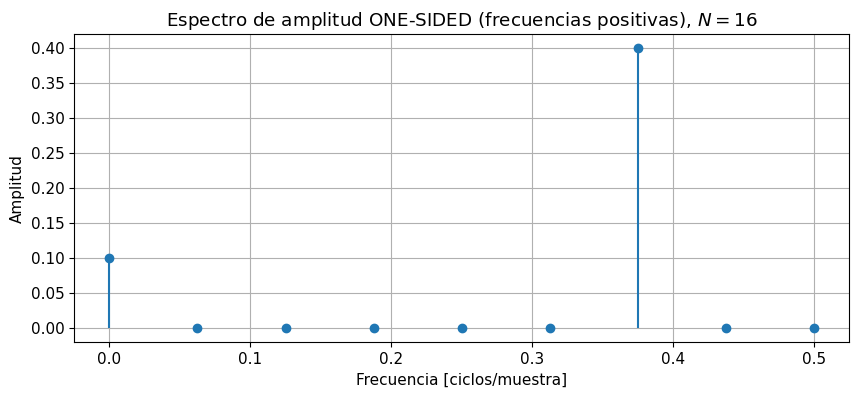

Amplitud del tono en bin k=6 (f=3/8): 0.4000
Amplitud esperada: 0.4 (amplitud original de la sinusoide)
Componente DC: 0.1000 (esperado: 0.1)


In [19]:
# === VALIDACIÓN ===
assert AfreqOneSided is not None, "Construye el espectro one-sided"
assert len(AfreqOneSided) == N // 2 + 1, f"El one-sided debe tener {N//2+1} muestras"

# Creamos el vector esperado según la fórmula:
AfreqOneSided_expected = Afreq[:N//2+1].copy()
AfreqOneSided_expected[1:-1] *= 2  # Duplicamos las amplitudes excepto DC y Nyquist
assert np.allclose(AfreqOneSided, AfreqOneSided_expected), (
    "AfreqOneSided no cumple la fórmula: debe ser igual a Afreqcompleto[:N//2+1], "
    "multiplicando por 2 todos los elementos salvo el primero (DC) y el último (Nyquist, si N par)"
)

# Compara AfreqOneSided y AfreqOneSided_rfft para verificar que son iguales
assert np.allclose(AfreqOneSided, AfreqOneSided_rfft), "Los dos espectros one-sided deben ser iguales"

print("rrft() proporciona el mismo resultado que el método manual")
print(f"AfreqOneSided = {AfreqOneSided}")
print(f"AfreqOneSided_rfft = {AfreqOneSided_rfft}")
print(f"ECMrrft = {ECMrrft}")


# === VISUALIZACIÓN ===
Fk_os = [Fraction(k, N) for k in range(0, N // 2 + 1)]
fk_os_float = [float(f) for f in Fk_os]

plt.figure(figsize=(10, 4))
plt.stem(Fk_os, AfreqOneSided, basefmt=' ')
plt.xlabel('Frecuencia [ciclos/muestra]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud ONE-SIDED (frecuencias positivas), $N = {N}$')
plt.show()

# Verificación de amplitudes
idx_tono = int(Fa / Fs * N)  # bin del tono
print(f"Amplitud del tono en bin k={idx_tono} (f={Fraction(idx_tono,N)}): {AfreqOneSided[idx_tono]:.4f}")
print(f"Amplitud esperada: {A} (amplitud original de la sinusoide)")
print(f"Componente DC: {AfreqOneSided[0]:.4f} (esperado: {C})")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Por qué duplicamos las amplitudes de las frecuencias positivas (excepto DC y Nyquist)?**

*Tu respuesta:*

```
Duplicamos las amplitudes de las frecuencias positivas (excepto DC y Nyquist) para conservar la energía total de la señal en el espectro one-sided. Dado que las frecuencias negativas son redundantes debido a la simetría conjugada de la DFT, al eliminar las frecuencias negativas, estamos perdiendo la mitad de la energía que contribuyen esas componentes. Al duplicar las amplitudes de las frecuencias positivas, compensamos esta pérdida y aseguramos que el espectro one-sided refleje correctamente la amplitud física de la señal original.
```

**2. ¿La amplitud del tono en el one-sided coincide con la amplitud real $A$ de la sinusoide? ¿Y la componente DC con $C$?**

*Tu respuesta:*

```
Sí, la amplitud del tono en el espectro one-sided coincide con la amplitud real $A$ de la sinusoide después de duplicar las amplitudes de las frecuencias positivas. En este caso, si originalmente la amplitud del tono era 0.2 en el espectro centrado, al duplicarla se obtiene 0.4, que coincide con la amplitud real $A$ de la sinusoide. De manera similar, la componente DC en el espectro one-sided coincide con el valor $C$, ya que no se duplica y refleja directamente el valor medio de la señal.
```

**3. ¿Por qué la representación one-sided es la más habitual en aplicaciones prácticas?**

*Tu respuesta:*

```
La representación one-sided es la más habitual en aplicaciones prácticas porque proporciona una visión más clara y directa de las componentes de frecuencia que realmente contribuyen a la señal, eliminando la redundancia de las frecuencias negativas. Esto facilita la interpretación y el análisis del espectro, especialmente cuando se trabaja con señales reales, donde las frecuencias negativas no aportan información adicional. Además, al utilizar funciones como `np.fft.rfft`, se mejora la eficiencia computacional al calcular solo la parte no redundante del espectro.
```

### 🔍 Checkpoint del profesor (Parada 1)

- [ ] Señal $x(n)$ generada correctamente
- [ ] Espectro de amplitud (sin centrar) con picos identificados
- [ ] Espectro centrado con `fftshift` → deltas en $\pm 3/8$
- [ ] Espectro completo simétrico ($N+1$ muestras)
- [ ] Espectro one-sided con amplitudes recuperadas ($A = 0.4$, $C = 0.1$)

---

## Parte 6: La DFT y la frecuencia de muestreo $F_s$

### Contexto teórico

La FFT no interviene para nada la frecuencia de muestreo $F_s$. Para la DFT lo que cuenta es el número de puntos $N$. Somos nosotros quienes debemos interpretar la salida de acuerdo con $F_s$.

La correspondencia entre frecuencia normalizada $f_k$ y frecuencia en Hz $F_k$ es:

$$F_k = f_k \cdot F_s = \frac{k}{N} \cdot F_s$$

De esta forma:
- El intervalo $[0, 1)$ ciclos/muestra ↔ $[0, F_s)$ Hz
- El intervalo $[-1/2, 1/2)$ ciclos/muestra ↔ $[-F_s/2, F_s/2)$ Hz

La **resolución frecuencial** es:

$$\Delta F = \frac{F_s}{N} = \frac{1}{T_d}$$

donde $T_d = N / F_s$ es la duración de la ventana en segundos.

Por ejemplo, las $N$ muestras del espectro centrado en 0 de $x(n)$ se pueden ver en la siguiente imagen donde se muestran los valores de la frecuencia $f_k$ en ciclos/muestra y también los correspondientes a $F_k$ en Hz:

<img src="../helpers/fftshiftHz.svg" width="700"/>

---
### Representación en escala logarítmica

También es útil representar el espectro en **escala logarítmica (decibelios, dB)**:

$$A_{\text{dB}}(k) = 20 \cdot \log_{10}(A(k))$$

---

### Bloque 6 · Espectro en Hz y en dB

#### 📝 Hipótesis previa

**Preguntas:**

- Con $N = 16$ y $F_s = 8000$ Hz, ¿cuál es la resolución frecuencial $\Delta F$? La resolución frecuencial $\Delta F$ se calcula como $\Delta F = F_s / N$. Dado que $F_s = 8000$ Hz y $N = 16$, tenemos:
\Delta F = 8000 / 16 = 500 \text{ Hz}
- ¿En qué frecuencia en Hz esperas ver el pico del tono? El pico del tono se espera ver en la frecuencia correspondiente a $f_a = 3/8$ ciclos/muestra. Para convertir esto a Hz, utilizamos la fórmula $F_k = f_k \cdot F_s$. Por lo tanto:
F_a = (3/8) \cdot 8000 = 3000 \text{ Hz}


In [23]:
# === IMPLEMENTACIÓN ===

# TODO: Calcula la resolución frecuencial, DeltaF
DeltaF = Fs / N


# TODO: Calcula la duración de la ventana, Td
Td = N * Ts  # Duración de la ventana en segundos


# TODO: Calcula el espectro de amplituden dB, AdB
AdB = 20 * np.log10(AfreqOneSided + 1e-12)  # Espectro de amplitud en dB, con un pequeño valor para evitar log(0)



In [24]:
# TODO: Calcula el eje de ordenadas en kHz, Fk_Hz usando linespace
Fk_Hz = np.linspace(0, Fs / 2, N // 2 + 1)  # Eje de frecuencias en Hz para el espectro one-sided



In [25]:
assert DeltaF == 1/Td, "No están bien calculadas DeltaF y Td"

print(f"N = {N} muestras")
print(f"Fs = {Fs} Hz")
print(f"Resolución frecuencial: ΔF = {DeltaF} Hz")
print(f"Duración de la ventana: Td = {Td*1e3} ms")

N = 16 muestras
Fs = 8000 Hz
Resolución frecuencial: ΔF = 500.0 Hz
Duración de la ventana: Td = 2.0 ms


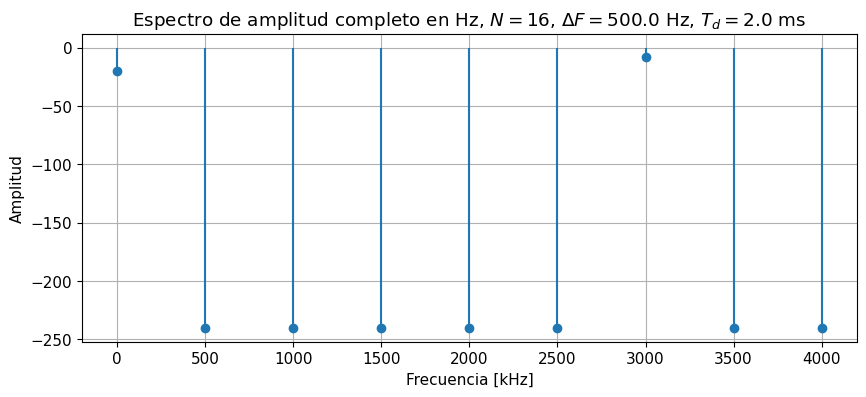

Pico del tono esperado en ±3.0 kHz


In [27]:
# === VISUALIZACIÓN: Espectro completo en Hz (escala lineal) ===
plt.figure(figsize=(10, 4))
plt.stem(Fk_Hz, AdB, basefmt=' ')
plt.xlabel('Frecuencia [kHz]')
plt.ylabel('Amplitud')
plt.title(f'Espectro de amplitud completo en Hz, $N = {N}$, $\\Delta F = {DeltaF}$ Hz, $T_d = {Td*1e3}$ ms')
plt.show()

print(f"Pico del tono esperado en ±{Fa/1e3} kHz")

In [ ]:
# === VALIDACIÓN ===
assert AdB is not None, "Calcula el espectro en dB"

plt.figure(figsize=(10, 4))
plt.stem(Fk_Hz, AdB, basefmt=' ')
plt.xlabel('Frecuencia [kHz]')
plt.ylabel('Amplitud [dB]')
plt.title(f'Espectro de amplitud en dB, $N = {N}$, $\\Delta F = {DeltaF}$ Hz')
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué determina la resolución frecuencial: $F_s$, $N$ o ambos?**

*Tu respuesta:*

```
La resolución frecuencial está determinada por ambos, $F_s$ y $N$. La fórmula para la resolución frecuencial es $\Delta F = F_s / N$, lo que significa que tanto la frecuencia de muestreo $F_s$ como el número de puntos $N$ afectan la capacidad de distinguir entre diferentes componentes de frecuencia en el espectro. Un mayor $F_s$ o un menor $N$ resultará en una mayor resolución frecuencial, mientras que un menor $F_s$ o un mayor $N$ resultará en una menor resolución frecuencial.
```

**2. ¿Qué diferencias fundamentales encuentras entre el espectro en escala lineal y logarítmica (dB)?**

*Tu respuesta:*

```
La principal diferencia entre el espectro en escala lineal y logarítmica (dB) es cómo se representan las amplitudes de las componentes de frecuencia. En escala lineal, las amplitudes se representan directamente, lo que puede dificultar la visualización de componentes con amplitudes muy pequeñas en comparación con otras más grandes. En cambio, en escala logarítmica (dB), las amplitudes se representan en una escala logarítmica, lo que permite visualizar mejor las componentes de frecuencia con amplitudes pequeñas, ya que la escala logarítmica amplifica las diferencias entre valores pequeños y grandes. Además, la escala logarítmica es más adecuada para representar la percepción humana del sonido, ya que el oído humano percibe las diferencias de amplitud de manera logarítmica.
```

**3. ¿Es posible conocer el valor del espectro para una frecuencia arbitraria (por ejemplo, 3.2 kHz)? ¿Por qué?**

*Tu respuesta:*

```
No, no es posible conocer el valor del espectro para una frecuencia arbitraria como 3.2 kHz utilizando la DFT, ya que la DFT solo proporciona valores para frecuencias discretas que corresponden a los bins definidos por $N$ y $F_s$. La frecuencia de 3.2 kHz no coincide con ninguna de las frecuencias discretas representadas en el espectro, por lo que no se puede obtener un valor exacto para esa frecuencia específica a partir de la DFT. Para obtener información sobre frecuencias arbitrarias, se necesitaría utilizar técnicas de interpolación o métodos de análisis espectral más avanzados.
```

**4. ¿Qué ventaja tiene la representación en decibelios?**

*Tu respuesta:*

```
La representación en decibelios tiene la ventaja de permitir una visualización más clara de las componentes de frecuencia con amplitudes muy pequeñas en comparación con otras más grandes. Al utilizar una escala logarítmica, se amplifican las diferencias entre valores pequeños y grandes, lo que facilita la identificación de componentes de frecuencia que podrían ser difíciles de distinguir en una escala lineal. Además, la representación en decibelios es más adecuada para representar la percepción humana del sonido, ya que el oído humano percibe las diferencias de amplitud de manera logarítmica, lo que hace que esta representación sea más intuitiva para analizar señales acústicas.
```

---

## Parte 7: Propiedades de la DFT — Parseval y linealidad

### Bloque 7a · Propiedad de Parseval

La energía de una señal es la misma en el dominio del tiempo y en el de la frecuencia:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$



In [ ]:
# === IMPLEMENTACIÓN: PARSEVAL ===
# TODO: Calcula la DFT de la señal usada para la DFT de N puntos (bloque 2), X
X = np.fft.fft(xtime, N)

# TODO: Calcula la energía en tiempo (Parseval), E_tiempo
E_tiempo = np.sum(np.abs(xtime) ** 2)

# TODO: Calcula la energía en frecuencia (Parseval), E_freq
E_freq = (1 / N) * np.sum(np.abs(X) ** 2)



In [29]:
# === VALIDACIÓN ===
assert E_tiempo is not None, "Calcula la energía en tiempo"
assert E_freq is not None, "Calcula la energía en frecuencia"
assert np.allclose(E_tiempo, E_freq), "Parseval no se cumple"

print(f"✓ PARSEVAL VERIFICADA")
print(f"Energía en tiempo: E_tiempo = {E_tiempo:.2e}")
print(f"Energía en frecuencia: E_freq = {E_freq:.2e}")

AssertionError: Parseval no se cumple


### Bloque 7b · Propiedad de linealidad

$$\text{DFT}\{a \cdot x_1[n] + b \cdot x_2[n]\} = a \cdot \text{DFT}\{x_1[n]\} + b \cdot \text{DFT}\{x_2[n]\}$$

In [ ]:
# === IMPLEMENTACIÓN: LINEALIDAD ===
# Señal 1: x del bloque 1
x1 = x
# Señal 2
F2=2000
A2=0.6
x2 = A2 * np.sin(2 * np.pi * F2/Fs * n)

# Combinación en tiempo
x_suma = x1 + x2

# TODO: Calcula la DFT de x_suma, X_suma


# TODO: Calcula la DFT de x1 y x2, X1 y X2, respectivamente


# TODO: Calcula la DFT de la combinación lineal, X_suma_espectral


In [ ]:
# === VALIDACIÓN LINEALIDAD ===
assert np.allclose(X_suma, X_suma_espectral), "Linealidad no se cumple"
ecm_suma = np.max(np.abs(X_suma - X_suma_espectral))

print(f"✓ LINEALIDAD VERIFICADA")
print(f"DFT(x1 + x2) vs DFT(x1) + DFT(x2)")
print(f"Error cuadrático medio: {ecm_suma:.2e}")

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Por qué Parseval es importante para validar cálculos de DFT?**

*Tu respuesta:*

```
[Escribe aquí]
```

**2. ¿Qué significa intuitivamente que la DFT sea una operación lineal?**

*Tu respuesta:*

```
[Escribe aquí]
```

---

## 🚀 Extensiones opcionales

### Extensión A: Eje de frecuencias con `fftfreq` vs `linspace`
Construye el eje de frecuencias de dos formas alternativas y comprueba que son equivalentes:
- Método 1: `np.fft.fftfreq(N, 1/Fs)`
- Método 2: `np.linspace(0, Fs - Fs/N, N)`

---

## Preguntas de control

### P1. ¿Qué hace `fftshift` y por qué la representación centrada es más natural?

*Tu respuesta:*

```
[Escribe aquí]
```

---

### P2. ¿Por qué la FFT de una señal real presenta simetría conjugada?

*Tu respuesta:*

```
[Escribe aquí]
```

---

### P3. ¿Por qué hay que normalizar el espectro para recuperar amplitudes?

*Tu respuesta:*

```
[Escribe aquí]
```

---

### P4. Si quieres ver mejor dos tonos cercanos, ¿qué debes cambiar?

*Tu respuesta:*

```
[Escribe aquí]
```

---

## ✅ Checklist final

- [ ] Run All sin errores
- [ ] Señal generada y visualizada con `stem()`
- [ ] Espectro de amplitud (sin centrar) en ciclos/muestra
- [ ] Espectro centrado con `fftshift`
- [ ] Espectro completo simétrico ($N+1$ muestras)
- [ ] Espectro one-sided con amplitudes correctas
- [ ] Espectro en Hz y en dB
- [ ] Propiedad de Parseval verificada
- [ ] Propiedad de linealidad verificada
- [ ] Todas las explicaciones completadas
- [ ] Preguntas de control respondidas

---

## 📚 Resumen de conceptos clave

| Concepto | Fórmula/Descripción |
|----------|--------------------|
| **DFT** | $X(k) = \sum_{n=0}^{N-1} x(n)\, e^{-j 2\pi k n / N}$ |
| **Espectro de amplitud** | $A(k) = \frac{1}{N}\|X(k)\|$ |
| **Frecuencia normalizada** | $f_k = k/N$ ciclos/muestra |
| **Frecuencia en Hz** | $F_k = f_k \cdot F_s = k \cdot \Delta F$ |
| **Resolución frecuencial** | $\Delta F = F_s / N = 1 / T_d$ |
| **Centrado** | `np.fft.fftshift()` reordena de $[0,1)$ a $[-1/2, 1/2)$ |
| **One-sided** | Solo frecuencias positivas, ×2 normalización |
| **Simetría conjugada** | Señales reales: $\|X(k)\| = \|X(N-k)\|$ |
| **Parseval (DFT estándar)** | $\sum_{n=0}^{N-1} \lvert x[n]\rvert^2 = \frac{1}{N} \sum_{k=0}^{N-1} \lvert X[k]\rvert^2$ |
| **Escala dB** | $A_{\text{dB}} = 20 \cdot \log_{10}(A)$ |

---

## 🔗 Conexión con Taller 8

En el Taller 8 veremos:
- **Resolución frecuencial y Leakage**
- **Smearing**
- **Zero-padding**
- **Ventanas**

---

## 📖 Referencias

- John G. Proakis, Dimitris G. Manolakis, *Digital Signal Processing: Principles, Algorithms, and Applications*, 3rd edition, Prentice Hall, 1996.
- Holton, T. (2021). *Digital Signal Processing: Principles and Applications*. Cambridge: Cambridge University Press.
- [Interpret FFT results — GaussianWaves](https://www.gaussianwaves.com/2015/11/interpreting-fft-results-obtaining-magnitude-and-phase-information/)
- [The Power Spectrum — Neil Robertson (dsprelated.com)](https://www.dsprelated.com/showarticle/1004.php)
- [DFT Frequency Resolution Explained (Wave Walker DSP)](https://www.wavewalkerdsp.com/2022/03/16/dft-frequency-resolution-explained/)

---

**Fin del Taller 7**